In [18]:
# Import libraries
import os
import glob
import numpy as np
import pandas as pd
import cv2

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [20]:
# Import custom definitions
from definitions import *

print(f"Dataset path: {data_root}")
print(f"Meta path: {meta_path}")
print(f"Mass training data path: {new_mass_train_path}")
print(f"Mass test data path: {new_mass_test_path}")
print(f"Mass train tensor path: {mass_train_tensor_path}")
print(f"Mass test tensor path: {mass_test_tensor_path}")

Dataset path: C:\Users\lejam\Desktop\CBIS-DDSM\manifest-1748122768688
Meta path: C:\Users\lejam\Desktop\CBIS-DDSM\manifest-1748122768688\metadata.csv
Mass training data path: C:\Users\lejam\Desktop\CBIS-DDSM\manifest-1748122768688\new_mass_case_description_train_set.csv
Mass test data path: C:\Users\lejam\Desktop\CBIS-DDSM\manifest-1748122768688\new_mass_case_description_test_set.csv
Mass train tensor path: C:\Users\lejam\Desktop\CBIS-DDSM\manifest-1748122768688\mass_tensor\train
Mass test tensor path: C:\Users\lejam\Desktop\CBIS-DDSM\manifest-1748122768688\mass_tensor\test


# History

### Load history

In [21]:
history_df = pd.read_csv(os.path.join(data_root, 'history.csv'))

history_df.head(2)

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss
0,0.981480,2.608216e-04,1.311122e-04,3.185428,0.994980,3.878922e-10,3.878922e-10,0.568749
1,0.994859,4.166819e-10,4.166819e-10,0.522863,0.995013,3.905687e-10,3.905687e-10,0.513866


### Visualise history

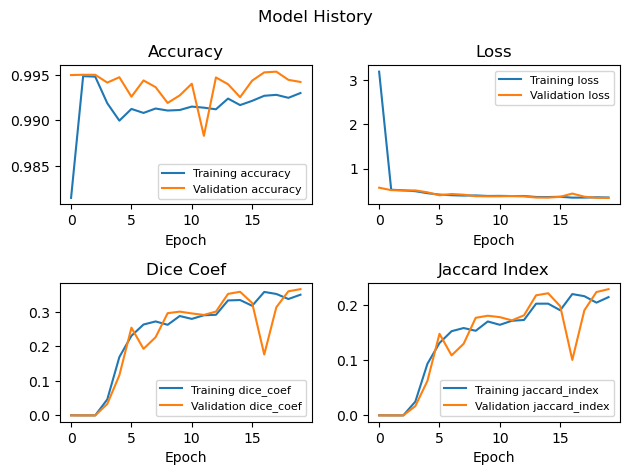

In [22]:
# Visualise model history
fig, ax = plt.subplots(2, 2)
fig.suptitle('Model History')
fontsize = 8

# Accuracy
ax[0,0].plot(history_df['accuracy'], label='Training accuracy')
ax[0,0].plot(history_df['val_accuracy'], label='Validation accuracy')
ax[0,0].set_title('Accuracy')
ax[0,0].set_xlabel('Epoch')
ax[0,0].legend(fontsize=fontsize)

# Loss
ax[0,1].plot(history_df['loss'], label='Training loss')
ax[0,1].plot(history_df['val_loss'], label='Validation loss')
ax[0,1].set_title('Loss')
ax[0,1].set_xlabel('Epoch')
ax[0,1].legend(fontsize=fontsize)

# Dice Coef
ax[1,0].plot(history_df['dice_coef'], label='Training dice_coef')
ax[1,0].plot(history_df['val_dice_coef'], label='Validation dice_coef')
ax[1,0].set_title('Dice Coef')
ax[1,0].set_xlabel('Epoch')
ax[1,0].legend(fontsize=fontsize)

# Dice Coef
ax[1,1].plot(history_df['jaccard_index'], label='Training jaccard_index')
ax[1,1].plot(history_df['val_jaccard_index'], label='Validation jaccard_index')
ax[1,1].set_title('Jaccard Index')
ax[1,1].set_xlabel('Epoch')
ax[1,1].legend(fontsize=fontsize)

plt.tight_layout()
plt.show()

# Model

### Load model

In [27]:
from tensorflow.keras import backend as K

# Dice Loss for segmentation (handles class imbalance)
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice
    
# Combined Binary Cross-Entropy and Dice loss for stability + region similarity
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return bce + 5 * d_loss

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * d_loss

# Dice Coefficient (Sørensen–Dice) for model evaluation
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # Apply threshold
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + smooth) / (union + smooth)
    
# Jaccard index (Intersection over Union) metric
def jaccard_index(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    # Threshold predicted masks to get binary output
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [29]:
# Load the saved model
loaded_model = tf.keras.models.load_model(
    os.path.join(data_root, 'mass_model.keras'),
    custom_objects={
        'combined_loss': combined_loss,
        'dice_coef': dice_coef,
        'jaccard_index': jaccard_index
})

### Model summary

In [30]:
loaded_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_133 (Conv2D)           │ (None, 128, 128, 64)      │           1,792 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_134 (Conv2D)           │ (None, 128, 128, 64)      │          36,928 │ conv2d_133[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_28              │ (None, 64, 64, 64)        │               0 │ conv2d_134[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_56 (Dropout)          │ (None, 64, 64, 64)        │               0 │ max_pooling2d_28[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_135 (Conv2D)           │ (None, 64, 64, 128)       │          73,856 │ dropout_56[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_136 (Conv2D)           │ (None, 64, 64, 128)       │         147,584 │ conv2d_135[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_29              │ (None, 32, 32, 128)       │               0 │ conv2d_136[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_57 (Dropout)          │ (None, 32, 32, 128)       │               0 │ max_pooling2d_29[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_137 (Conv2D)           │ (None, 32, 32, 256)       │         295,168 │ dropout_57[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_138 (Conv2D)           │ (None, 32, 32, 256)       │         590,080 │ conv2d_137[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_30              │ (None, 16, 16, 256)       │               0 │ conv2d_138[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_58 (Dropout)          │ (None, 16, 16, 256)       │               0 │ max_pooling2d_30[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_139 (Conv2D)           │ (None, 16, 16, 512)       │       1,180,160 │ dropout_58[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_140 (Conv2D)           │ (None, 16, 16, 512)       │       2,359,808 │ conv2d_139[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_31              │ (None, 8, 8, 512)         │               

 Total params: 103,540,037 (394.97 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,026,692 (263.32 MB)

### Evaluation

In [31]:
test_images = tf.data.Dataset.load(mass_test_tensor_path)
for x, y in test_images.take(1):
    print(f"test image shape: {x.shape}, {y.shape}")

test_rows = len(test_images)
val_size = int(0.8 * test_rows)
test_size = test_rows - val_size
BATCH_SIZE = 8

test_batches = (
    test_images
    .skip(val_size)
    .take(test_size)
    .batch(BATCH_SIZE)
)

test image shape: (128, 128, 3), (128, 128, 1)


In [32]:
evaluations = loaded_model.evaluate(test_batches)

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 755ms/step - accuracy: 0.9949 - dice_coef: 0.3904 - jaccard_index: 0.2535 - loss: 0.3246


In [33]:
print("Evaluation with test dataset:")
print(f"\tLoss: {evaluations[0]:.4f}")
print(f"\tAccuracy: {evaluations[1] * 100:.2f}%")

Evaluation with test dataset:
	Loss: 0.3050
	Accuracy: 99.53%


### Prediction

In [34]:
predictions = loaded_model.predict(test_batches)

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 768ms/step


In [35]:
print(f"predictions size: {predictions.shape}")

predictions size: (76, 128, 128, 1)


In [36]:
from sklearn.metrics import classification_report

y_true_all = []
y_pred_all = []

for images, masks in test_batches:
    preds = loaded_model.predict(images)  # Shape: (batch, 128, 128, 1)

    # Apply threshold to predicted masks
    preds = (preds > 0.5).astype(np.uint8)

    # Flatten both prediction and mask to compare pixel-wise
    y_true_all.extend(masks.numpy().flatten().astype(np.uint8))
    y_pred_all.extend(preds.flatten())

# Use sklearn classification report
print(classification_report(y_true_all, y_pred_all))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1238900
           1       0.54      0.43      0.48      6284

    accuracy                           1.00   1245184
   macro avg       0.77      0.71      0.74   1245184
weighted avg       0.99      1.00      1.00   1245184



In [37]:
def display(images):
    plt.figure(figsize=(7, 7))
    title = ["Input Image", "Ground Truth", "Predicted Mask"]
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(images[i]))
        plt.axis("off")
    plt.show()
    
def create_mask(pred_mask):
    if False:
        mask = tf.math.argmax(pred_mask, axis=-1)
        mask = mask[..., tf.newaxis]
    else:  
        mask = tf.cast(pred_mask > 0.5, tf.uint8)
    
    print(np.unique(pred_mask), np.unique(mask),
          pred_mask.min(), pred_mask.max(),
          pred_mask.shape, mask.shape)
    return mask[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step
[1.2272774e-33 1.8396086e-33 4.1856973e-33 ... 9.9389780e-01 9.9461550e-01
 9.9537879e-01] [0 1] 1.2272774e-33 0.9953788 (8, 128, 128, 1) (8, 128, 128, 1)


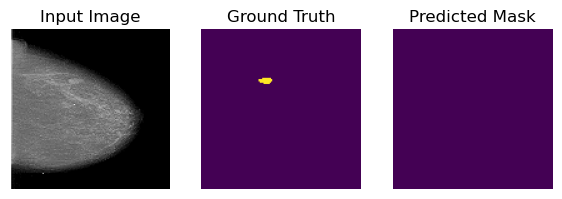

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
[1.9393554e-33 3.2867707e-33 2.3879166e-32 ... 9.9957460e-01 9.9964720e-01
 9.9965411e-01] [0 1] 1.9393554e-33 0.9996541 (8, 128, 128, 1) (8, 128, 128, 1)


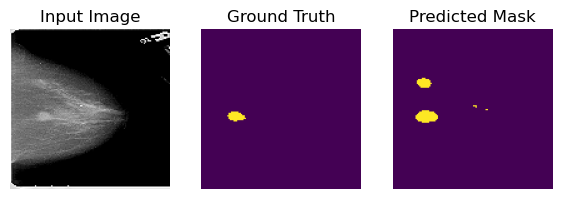

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
[3.5078509e-32 3.6015733e-32 3.8224643e-32 ... 9.9850374e-01 9.9864495e-01
 9.9876624e-01] [0 1] 3.507851e-32 0.99876624 (8, 128, 128, 1) (8, 128, 128, 1)


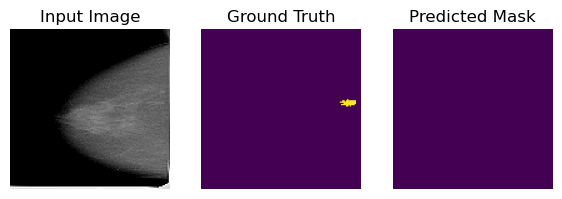

In [38]:
for image, mask in test_batches.take(3):
    pred_mask = loaded_model.predict(image)
    true_mask = mask[0] # tf.expand_dims(mask[0], axis=-1)
    
    display([image[0], true_mask, create_mask(pred_mask)])